### Импорты и настройка конфигурации

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [38]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", 50)

### Выгразка данных

In [39]:
path_dir_data = r"./data/data"
path_dir_submissions = r"./data/submit"

In [40]:
authors = pd.read_csv(path_dir_data + "/authors.csv")
book_genres = pd.read_csv(path_dir_data + "/book_genres.csv")
editions = pd.read_csv(path_dir_data + "/editions.csv")
genres = pd.read_csv(path_dir_data + "/genres.csv")
interactions = pd.read_csv(path_dir_data + "/interactions.csv")
users = pd.read_csv(path_dir_data + "/users.csv")

candidates = pd.read_csv(path_dir_submissions + "/candidates.csv")
example_submission = pd.read_csv(path_dir_submissions + "/example_submission.csv")
targets = pd.read_csv(path_dir_submissions + "/targets.csv")

interactions["event_ts"] = pd.to_datetime(interactions["event_ts"])
interactions = interactions[interactions["event_ts"] < pd.Timestamp("2025-01-14")]

### Первая проверка данных

#### Authors

In [41]:
authors.head()

,author_id,author_name
0,1,Грегори Бенфорд
1,6,Вячеслав Маркин
2,18,Эдвард де Боно
3,19,Василий Головачёв
4,21,Пауло Коэльо


#### Book_genres

In [42]:
book_genres.head()

,book_id,genre_id
0,20,433
1,20,1217
2,35,141
3,35,142
4,35,146


#### Genres

In [43]:
genres.head()

,genre_id,genre_name
0,1,Бизнес-книги
1,2,Банковское-дело
2,3,Бухучет-налогообложение-аудит
3,4,Государственное-и-муниципальное-управление
4,5,Делопроизводство


In [44]:
genres["genre_name"].value_counts().sort_values(ascending=False)

genre_name
Бизнес-книги                                  1
Банковское-дело                               1
Бухучет-налогообложение-аудит                 1
Государственное-и-муниципальное-управление    1
Делопроизводство                              1
                                             ..
Психологический-роман                         1
Славянское-фэнтези                            1
Ориентальное-фэнтези                          1
Вебтун                                        1
unknown                                       1
Name: count, Length: 586, dtype: int64

In [45]:
genres.info()

<class 'pandas.DataFrame'>
RangeIndex: 586 entries, 0 to 585
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   genre_id    586 non-null    int64
 1   genre_name  586 non-null    str  
dtypes: int64(1), str(1)
memory usage: 9.3 KB


In [46]:
for name in genres["genre_name"].tolist():
    mass = name.split(";")
    if len(mass) > 1:
        print(name)

#### Users

In [47]:
users.head()

,user_id,gender,age
0,560,2.0,9.0
1,3410,2.0,39.0
2,5620,1.0,42.0
3,5700,2.0,40.0
4,6120,2.0,32.0


In [48]:
users["gender"].value_counts()

gender
2.0    4311
1.0     585
Name: count, dtype: int64

In [49]:
users["age"].value_counts()

age
25.0    264
30.0    246
35.0    244
31.0    234
33.0    230
       ... 
77.0      1
99.0      1
72.0      1
87.0      1
6.0       1
Name: count, Length: 74, dtype: int64

Text(0.5, 1.0, 'Распределение по возрасту')

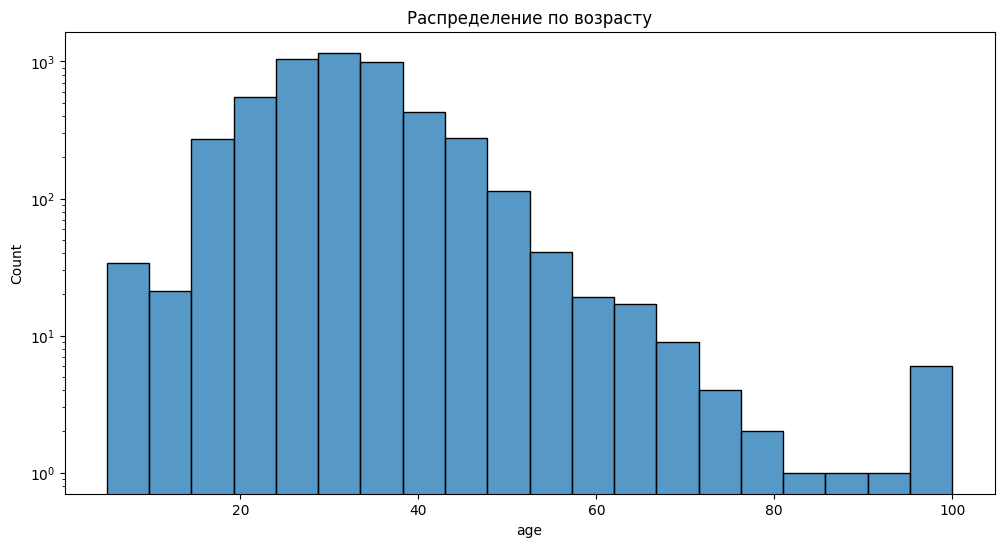

In [50]:
plt.figure(figsize=(12, 6))
sns.histplot(x="age", data=users, bins=20)
plt.yscale("log")
plt.title("Распределение по возрасту")

#### Editions

In [51]:
editions.head()

,edition_id,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description
0,1000000001,1093185,1.0,2000,18,119,9,Панорама времен,"Научный фантаст - тот, кто не стыдится первой ..."
1,1000000016,1548860,18.0,2005,16,119,1276,Развитие мышления: три пятидневных курса,"Талантливый ученый с мировым именем, изобретат..."
2,1000000020,20,21.0,2005,16,119,432,Вероника решает умереть,"Вторая изданная ""Софией"" книга Коэльо - совсем..."
3,1000000035,35,33.0,2002,18,119,122,Самое жуткое приключение,Когда Ларри Бойд и его друзья решили применить...
4,1000000070,891990,226891.0,2001,12,119,9,Танцы на снегу,«Звездные войны» от Сергея Лукьяненко? Да.\r\n...


In [52]:
editions.info()

<class 'pandas.DataFrame'>
RangeIndex: 134231 entries, 0 to 134230
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   edition_id        134231 non-null  int64  
 1   book_id           134231 non-null  int64  
 2   author_id         134231 non-null  float64
 3   publication_year  134231 non-null  int64  
 4   age_restriction   134231 non-null  int64  
 5   language_id       134231 non-null  int64  
 6   publisher_id      134231 non-null  int64  
 7   title             134231 non-null  str    
 8   description       126176 non-null  str    
dtypes: float64(1), int64(6), str(2)
memory usage: 9.2 MB


#### Interactions

In [53]:
interactions.head()

,user_id,edition_id,event_type,rating,event_ts
0,560,1012411658,2,6.0,2024-12-24 19:02:14
1,560,1008465904,2,6.0,2025-01-10 19:18:04
5,560,1010135515,2,NaN,2024-11-07 11:49:58
6,560,1012274951,2,NaN,2024-11-07 11:52:58
7,560,1012274954,2,8.0,2024-11-07 11:53:44


In [54]:
interactions.info()

<class 'pandas.DataFrame'>
Index: 111908 entries, 0 to 230795
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     111908 non-null  int64         
 1   edition_id  111908 non-null  int64         
 2   event_type  111908 non-null  int64         
 3   rating      60493 non-null   float64       
 4   event_ts    111908 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(3)
memory usage: 5.1 MB


In [55]:
interactions["user_id"].nunique()

4642

In [56]:
interactions["event_type"].value_counts()

event_type
2    70694
1    41214
Name: count, dtype: int64

In [57]:
interactions["user_id"].value_counts().sort_values(ascending=False)

user_id
11128820    239
11349200    229
10768850    205
11275490    204
7170520     201
           ... 
11540290      1
11548690      1
11558200      1
11561860      1
11563480      1
Name: count, Length: 4642, dtype: int64

In [58]:
interactions["event_ts"].min(), interactions["event_ts"].max()

(Timestamp('2024-10-14 18:48:56'), Timestamp('2025-01-13 23:59:52'))

#### Небольшая склейка, хочу проверить могут ли читать дети недостигшие возраста книги

In [59]:
interactions_editions = interactions.merge(editions, on="edition_id", how="left")
iter_users_editions = interactions_editions.merge(users, on="user_id", how="left")
iter_users_editions.head()

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description,gender,age
0,560,1012411658,2,6.0,2024-12-24 19:02:14,8387168,1085990.0,2024,16,119,123745,И время остановилось,"Во французском Берри, краю замков и зеленых по...",2.0,9.0
1,560,1008465904,2,6.0,2025-01-10 19:18:04,6064826,2338126.0,2023,16,119,1470,Смерть и круассаны,"Ричард Эйнсворт — хозяин небольшой гостиницы, ...",2.0,9.0
2,560,1010135515,2,NaN,2024-11-07 11:49:58,236262,4980.0,2024,16,119,78,Загадка Красной Вдовы,Золотой век детектива оставил немало звездных ...,2.0,9.0
3,560,1012274951,2,NaN,2024-11-07 11:52:58,1766588,4980.0,1933,16,119,78,Ведьмино логово,Золотой век детектива подарил нам множество зв...,2.0,9.0
4,560,1012274954,2,8.0,2024-11-07 11:53:44,851821,4980.0,2024,16,119,78,Тайна Безумного Шляпника,Золотой век детектива подарил нам множество зв...,2.0,9.0


In [60]:
iter_users_editions[["age_restriction", "age"]].head()

,age_restriction,age
0,16,9.0
1,16,9.0
2,16,9.0
3,16,9.0
4,16,9.0


#### Вывод

Сразу видим, что возрастные ограничения не играют роли

Небольшой подитог: у нас есть множество таблиц, связанных через ключевые столбцы между собой. Датасеты небольшие, размером до 250000. Данные обширны, имеют много лишней информации. Всего примерно 5000 читателей найдено. Большая часть девушки. В основном читают люди 20-30 лет. После 45 происходит резкое снижение. Период сбора данных полгода. 

Вероятно стоит далее убрать лишние данные, сделать агрегации по пользователям, авторам, жанрам, полу, возрасту, книгам и возможно оценить тренды по сезонам.

### Общий датасет

In [61]:
genres_mas = (book_genres.groupby("book_id")["genre_id"].apply(list).reset_index())
genres_mas

,book_id,genre_id
0,20,"[433, 1217]"
1,35,"[141, 142, 146, 1223]"
2,54,"[125, 127, 433]"
3,69,"[127, 1280]"
4,72,"[128, 1311, 1312]"
...,...,...
105747,11339524,"[412, 441, 1223]"
105748,11340301,[433]
105749,11342272,[141]
105750,11342305,[1394]


In [62]:
train = interactions.merge(editions, on="edition_id", how="left")
train = train.merge(users, on="user_id", how="left")
train = train.merge(genres_mas, on="book_id", how="left")
train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description,gender,age,genre_id
0,560,1012411658,2,6.0,2024-12-24 19:02:14,8387168,1085990.0,2024,16,119,123745,И время остановилось,"Во французском Берри, краю замков и зеленых по...",2.0,9.0,[433]
1,560,1008465904,2,6.0,2025-01-10 19:18:04,6064826,2338126.0,2023,16,119,1470,Смерть и круассаны,"Ричард Эйнсворт — хозяин небольшой гостиницы, ...",2.0,9.0,"[127, 128, 1276]"
2,560,1010135515,2,NaN,2024-11-07 11:49:58,236262,4980.0,2024,16,119,78,Загадка Красной Вдовы,Золотой век детектива оставил немало звездных ...,2.0,9.0,"[127, 130]"
3,560,1012274951,2,NaN,2024-11-07 11:52:58,1766588,4980.0,1933,16,119,78,Ведьмино логово,Золотой век детектива подарил нам множество зв...,2.0,9.0,"[127, 130]"
4,560,1012274954,2,8.0,2024-11-07 11:53:44,851821,4980.0,2024,16,119,78,Тайна Безумного Шляпника,Золотой век детектива подарил нам множество зв...,2.0,9.0,"[127, 130]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111903,11928010,1007062723,2,NaN,2024-11-19 02:08:55,3693046,200020.0,2021,16,119,63851,Как стать леди,Впервые на русском – одна из главных книг клас...,2.0,20.0,"[412, 444]"
111904,11928010,1012244726,2,NaN,2024-11-24 16:59:53,455521,235846.0,2024,16,119,7,Север и юг,Элизабет Гаскелл – известная британская писате...,2.0,20.0,"[412, 441, 529, 1333]"
111905,11928010,1011979760,2,NaN,2024-12-05 21:06:34,3146386,2071510.0,2022,16,119,70351,Лисий дом,Для всех любителей азиатской культуры и класси...,2.0,20.0,[1249]
111906,11928010,1012248659,2,NaN,2024-12-08 15:57:00,6512014,1392205.0,2024,16,119,65088,Девушка из стекла,Жизнь Вероники Уилкинс давно превратилась в ун...,2.0,20.0,[1251]


### Обработка NAN

In [63]:
train.isna().sum()

user_id                 0
edition_id              0
event_type              0
rating              51415
event_ts                0
book_id                 0
author_id               0
publication_year        0
age_restriction         0
language_id             0
publisher_id            0
title                   0
description          2167
gender               3157
age                  1891
genre_id                0
dtype: int64

In [64]:
train["rating"] = train["rating"].fillna(round(train["rating"].mean())).astype("int64")
train["description"] = train["description"].fillna("")
train["gender"] = train["gender"].fillna(train["gender"].mode()[0]).astype("int64")
train["age"] = train["age"].fillna(round(train["age"].mean())).astype("int64")

In [65]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 111908 entries, 0 to 111907
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   user_id           111908 non-null  int64         
 1   edition_id        111908 non-null  int64         
 2   event_type        111908 non-null  int64         
 3   rating            111908 non-null  int64         
 4   event_ts          111908 non-null  datetime64[us]
 5   book_id           111908 non-null  int64         
 6   author_id         111908 non-null  float64       
 7   publication_year  111908 non-null  int64         
 8   age_restriction   111908 non-null  int64         
 9   language_id       111908 non-null  int64         
 10  publisher_id      111908 non-null  int64         
 11  title             111908 non-null  str           
 12  description       111908 non-null  str           
 13  gender            111908 non-null  int64         
 14  age            

### Удаляем лишнее, дополнительный анализ (стадия 2)

In [66]:
train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,age_restriction,language_id,publisher_id,title,description,gender,age,genre_id
0,560,1012411658,2,6,2024-12-24 19:02:14,8387168,1085990.0,2024,16,119,123745,И время остановилось,"Во французском Берри, краю замков и зеленых по...",2,9,[433]
1,560,1008465904,2,6,2025-01-10 19:18:04,6064826,2338126.0,2023,16,119,1470,Смерть и круассаны,"Ричард Эйнсворт — хозяин небольшой гостиницы, ...",2,9,"[127, 128, 1276]"
2,560,1010135515,2,8,2024-11-07 11:49:58,236262,4980.0,2024,16,119,78,Загадка Красной Вдовы,Золотой век детектива оставил немало звездных ...,2,9,"[127, 130]"
3,560,1012274951,2,8,2024-11-07 11:52:58,1766588,4980.0,1933,16,119,78,Ведьмино логово,Золотой век детектива подарил нам множество зв...,2,9,"[127, 130]"
4,560,1012274954,2,8,2024-11-07 11:53:44,851821,4980.0,2024,16,119,78,Тайна Безумного Шляпника,Золотой век детектива подарил нам множество зв...,2,9,"[127, 130]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111903,11928010,1007062723,2,8,2024-11-19 02:08:55,3693046,200020.0,2021,16,119,63851,Как стать леди,Впервые на русском – одна из главных книг клас...,2,20,"[412, 444]"
111904,11928010,1012244726,2,8,2024-11-24 16:59:53,455521,235846.0,2024,16,119,7,Север и юг,Элизабет Гаскелл – известная британская писате...,2,20,"[412, 441, 529, 1333]"
111905,11928010,1011979760,2,8,2024-12-05 21:06:34,3146386,2071510.0,2022,16,119,70351,Лисий дом,Для всех любителей азиатской культуры и класси...,2,20,[1249]
111906,11928010,1012248659,2,8,2024-12-08 15:57:00,6512014,1392205.0,2024,16,119,65088,Девушка из стекла,Жизнь Вероники Уилкинс давно превратилась в ун...,2,20,[1251]


In [67]:
df_train = train.drop(columns=["description", "title", "age_restriction"])
df_train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,language_id,publisher_id,gender,age,genre_id
0,560,1012411658,2,6,2024-12-24 19:02:14,8387168,1085990.0,2024,119,123745,2,9,[433]
1,560,1008465904,2,6,2025-01-10 19:18:04,6064826,2338126.0,2023,119,1470,2,9,"[127, 128, 1276]"
2,560,1010135515,2,8,2024-11-07 11:49:58,236262,4980.0,2024,119,78,2,9,"[127, 130]"
3,560,1012274951,2,8,2024-11-07 11:52:58,1766588,4980.0,1933,119,78,2,9,"[127, 130]"
4,560,1012274954,2,8,2024-11-07 11:53:44,851821,4980.0,2024,119,78,2,9,"[127, 130]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
111903,11928010,1007062723,2,8,2024-11-19 02:08:55,3693046,200020.0,2021,119,63851,2,20,"[412, 444]"
111904,11928010,1012244726,2,8,2024-11-24 16:59:53,455521,235846.0,2024,119,7,2,20,"[412, 441, 529, 1333]"
111905,11928010,1011979760,2,8,2024-12-05 21:06:34,3146386,2071510.0,2022,119,70351,2,20,[1249]
111906,11928010,1012248659,2,8,2024-12-08 15:57:00,6512014,1392205.0,2024,119,65088,2,20,[1251]


<Axes: xlabel='publication_year', ylabel='Count'>

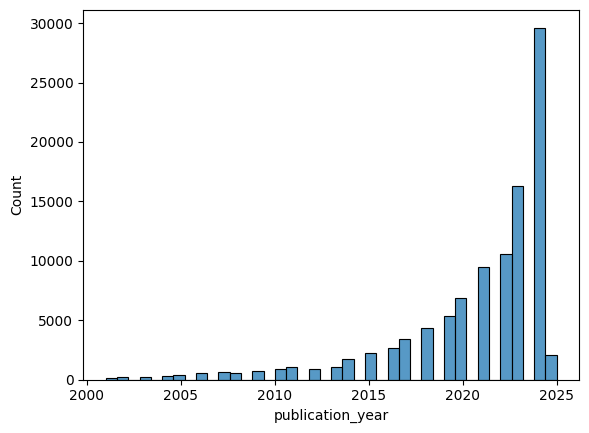

In [68]:
sns.histplot(x=df_train[df_train["publication_year"] > 2000]["publication_year"], bins=40)

### Агрегации

#### По годам публикации

In [69]:
read_in_publ = df_train.groupby("publication_year").size().reset_index(name="counts").sort_values(by="counts", ascending=False)
read_in_publ = read_in_publ.reset_index(drop=True)

rank_map = {}
for i, y in enumerate(read_in_publ["publication_year"]):
    if y == 2025 or y == 2026:
        rank_map[y] = 10
    else:
        rank_map[y] = max(1, 10 - i // 2)

df_train["year_rank"] = df_train["publication_year"].map(rank_map)


#### По количеству лет пользователей

In [70]:
age_rank_ = df_train.groupby("age").size().reset_index(name="counts").sort_values(by="counts", ascending=False).reset_index(drop=True)

age_rank_map = {}
for i, y in enumerate(age_rank_["age"]):
    age_rank_map[y] = max(1, 10 - i // 5)

df_train["age_rank"] = df_train["age"].map(age_rank_map)

#### По авторам

In [71]:
score_mass = []
score = 10
for i in range(3, 12):
    score_mass.append(score)
    score *= 2

number_month = len(df_train["event_ts"].dt.month.unique().tolist())
div = np.sqrt(6 / number_month)
score_mass = [score / div for score in score_mass]
print(div)
print(score_mass)

1.224744871391589
[np.float64(8.16496580927726), np.float64(16.32993161855452), np.float64(32.65986323710904), np.float64(65.31972647421809), np.float64(130.63945294843617), np.float64(261.27890589687235), np.float64(522.5578117937447), np.float64(1045.1156235874894), np.float64(2090.2312471749788)]


In [72]:
authors_rank_ = df_train.groupby("author_id").size().reset_index(name="counts").sort_values(by="counts", ascending=False).reset_index(drop=True)

authors_rank_map = {}
for i, y in enumerate(authors_rank_["author_id"]):
    for rank_inv, val in enumerate(score_mass):
        if i < val:
            authors_rank_map[y] = 10 - rank_inv
            break
    else:
        authors_rank_map[y] =  1

df_train["author_rank"] = df_train["author_id"].map(authors_rank_map)

#### По языку

In [73]:
df_train["language_flag"] = df_train["language_id"].apply(lambda x: 1 if x == 119 else 0)

In [74]:
user_multi_lang_flag = df_train.groupby("user_id")["language_id"].apply(set).apply(len).apply(lambda x: 1 if x > 1 else 0)
df_train["user_multi_lang_flag"] = df_train["user_id"].map(user_multi_lang_flag)

In [75]:
df_train

,user_id,edition_id,event_type,rating,event_ts,book_id,author_id,publication_year,language_id,publisher_id,gender,age,genre_id,year_rank,age_rank,author_rank,language_flag,user_multi_lang_flag
0,560,1012411658,2,6,2024-12-24 19:02:14,8387168,1085990.0,2024,119,123745,2,9,[433],10,1,1,1,0
1,560,1008465904,2,6,2025-01-10 19:18:04,6064826,2338126.0,2023,119,1470,2,9,"[127, 128, 1276]",10,1,1,1,0
2,560,1010135515,2,8,2024-11-07 11:49:58,236262,4980.0,2024,119,78,2,9,"[127, 130]",10,1,4,1,0
3,560,1012274951,2,8,2024-11-07 11:52:58,1766588,4980.0,1933,119,78,2,9,"[127, 130]",1,1,4,1,0
4,560,1012274954,2,8,2024-11-07 11:53:44,851821,4980.0,2024,119,78,2,9,"[127, 130]",10,1,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111903,11928010,1007062723,2,8,2024-11-19 02:08:55,3693046,200020.0,2021,119,63851,2,20,"[412, 444]",9,6,4,1,0
111904,11928010,1012244726,2,8,2024-11-24 16:59:53,455521,235846.0,2024,119,7,2,20,"[412, 441, 529, 1333]",10,6,4,1,0
111905,11928010,1011979760,2,8,2024-12-05 21:06:34,3146386,2071510.0,2022,119,70351,2,20,[1249],9,6,1,1,0
111906,11928010,1012248659,2,8,2024-12-08 15:57:00,6512014,1392205.0,2024,119,65088,2,20,[1251],10,6,2,1,0


#### По книгам

In [76]:
score_mass = []
score = 10
for i in range(3, 12):
    score_mass.append(score)
    score = round(score * 1.75)
print(score_mass)

[10, 18, 32, 56, 98, 172, 301, 527, 922]


In [77]:
book_rank_ = df_train.groupby("book_id").size().reset_index(name="counts").sort_values(by="counts", ascending=False).reset_index(drop=True)

book_rank_map = {}
for i, y in enumerate(book_rank_["book_id"]):
    for rank_inv, val in enumerate(score_mass):
        if i < val:
            book_rank_map[y] = 10 - rank_inv
            break
    else:
        book_rank_map[y] =  1

df_train["book_rank"] = df_train["book_id"].map(book_rank_map)

#### Жанры

In [78]:
df_train["n_genres"] = df_train["genre_id"].apply(len)

In [79]:
top_genres = df_train["genre_id"].explode().value_counts()

df_train["main_genre"] = df_train["genre_id"].apply(
    lambda xs: max(xs, key=lambda g: top_genres.get(g, 0))
)

In [80]:
df_train["genre_popularity_sum"] = df_train["genre_id"].apply(
    lambda xs: sum(top_genres.get(g, 0) for g in xs)
)

In [81]:
df_train["genre_popularity_mean"] = (
    df_train["genre_popularity_sum"] / df_train["n_genres"]
)

In [82]:
df_train["is_multigenre"] = (df_train["n_genres"] > 1).astype(int)

#### Пользователь\жанры (сколько книг с такими жанрами читал пользователь)

In [83]:
user_genre_cnt = df_train.explode("genre_id").groupby(["user_id", "genre_id"]).size()
df_train["user_genre_cnt"] = df_train.apply(lambda x: sum(user_genre_cnt.get((x.user_id, g) , 0 ) for g in x.genre_id), axis=1)

#### Пользователь\автор сколько взаимодействий

In [84]:
user_author_cnt = df_train.groupby(["user_id", "author_id"]).size()
df_train["user_author_hits"] = df_train.apply(
    lambda r: user_author_cnt.get((r.user_id, r.author_id), 0),
    axis=1
)

#### Логарифмирование некоторых признаков

In [85]:
df_train["genre_popularity_sum"] = np.log1p(df_train["genre_popularity_sum"])
df_train["genre_popularity_mean"] = np.log1p(df_train["genre_popularity_mean"])


#### Суммарный ранг

In [86]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 111908 entries, 0 to 111907
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                111908 non-null  int64         
 1   edition_id             111908 non-null  int64         
 2   event_type             111908 non-null  int64         
 3   rating                 111908 non-null  int64         
 4   event_ts               111908 non-null  datetime64[us]
 5   book_id                111908 non-null  int64         
 6   author_id              111908 non-null  float64       
 7   publication_year       111908 non-null  int64         
 8   language_id            111908 non-null  int64         
 9   publisher_id           111908 non-null  int64         
 10  gender                 111908 non-null  int64         
 11  age                    111908 non-null  int64         
 12  genre_id               111908 non-null  object        


In [87]:
df_train["total_rank"] = df_train[["author_rank", "rating", "book_rank", "year_rank"]].agg(sum, axis=1)

### Векторы пользователей и авторов

In [88]:
user_vec = df_train.groupby("user_id").agg(
    genre_pop_mean= ("genre_popularity_mean", "mean"),
    language_multi_flag= ("user_multi_lang_flag", "mean"),
    rating_mean= ("rating", "mean"),
    author_rank_mean= ("author_rank", "mean"),
    book_rank_mean= ("book_rank", "mean"),
    year_rank_mean= ("year_rank", "mean"),
    total_rank_mean= ("total_rank", "mean"),
    n_genres_mean=("n_genres", "mean")
)
user_ind = user_vec.index
user_vec = normalize(user_vec.values)

user_vec = pd.DataFrame(user_vec, index=user_ind)

In [89]:
author_vec = (
    df_train
    .groupby("author_id")
    .agg(
        genre_pop_mean=("genre_popularity_mean", "mean"),
        year_rank_mean=("year_rank", "mean"),
        book_rank_mean=("book_rank", "mean"),
        n_genres_mean=("n_genres", "mean"),
        rating_mean=("rating", "mean"),
    )
)
author_ind = author_vec.index
author_vec= normalize(author_vec.values)

author_vec = pd.DataFrame(author_vec, index=author_ind)

### Кластеры

In [90]:
user_clusters = KMeans(n_clusters=75, random_state=42).fit_predict(user_vec)
author_clusters = KMeans(n_clusters=45, random_state=42).fit_predict(author_vec)

In [91]:
user_vec["user_cluster"] = user_clusters
author_vec["author_cluster"] = author_clusters

In [92]:
df_train = df_train.merge(user_vec["user_cluster"], on="user_id", how="left")
df_train = df_train.merge(author_vec["author_cluster"], on="author_id", how="left")


In [93]:
COMMON_FEATS = list(
    set(user_vec.columns)
    & set(author_vec.columns)
)
COMMON_FEATS

[0, 1, 2, 3, 4]

In [95]:
u = user_vec.reset_index()[["user_id", *COMMON_FEATS]].rename(
    columns={c: f"{c}_u" for c in COMMON_FEATS}
)
a = author_vec.reset_index()[["author_id", *COMMON_FEATS]].rename(
    columns={c: f"{c}_a" for c in COMMON_FEATS}
)

df = df_train.merge(u, on="user_id", how="left")
df = df.merge(a, on="author_id", how="left")

u_mat = df[[f"{c}_u" for c in COMMON_FEATS]].to_numpy()
a_mat = df[[f"{c}_a" for c in COMMON_FEATS]].to_numpy()

num = (u_mat * a_mat).sum(axis=1)
den = (np.linalg.norm(u_mat, axis=1) * np.linalg.norm(a_mat, axis=1))
df_train["user_author_sim"] = num / den

### Последнее удаление, лишних фич

In [96]:
df_train.drop(columns=["publisher_id", "author_id", "book_id"], inplace=True)

### Итоговый датасет данных

In [97]:
df_train["event_ts"] = pd.to_datetime(df_train["event_ts"])
df_train

,user_id,edition_id,event_type,rating,event_ts,publication_year,language_id,gender,age,genre_id,year_rank,age_rank,author_rank,language_flag,user_multi_lang_flag,book_rank,n_genres,main_genre,genre_popularity_sum,genre_popularity_mean,is_multigenre,user_genre_cnt,user_author_hits,total_rank,user_cluster,author_cluster,user_author_sim
0,560,1012411658,2,6,2024-12-24 19:02:14,2024,119,2,9,[433],10,1,1,1,0,1,1,433,9.811866,9.811866,0,5,1,18,62,32,0.562514
1,560,1008465904,2,6,2025-01-10 19:18:04,2023,119,2,9,"[127, 128, 1276]",10,1,1,1,0,1,3,127,9.052165,7.953787,1,6,1,18,62,11,0.539689
2,560,1010135515,2,8,2024-11-07 11:49:58,2024,119,2,9,"[127, 130]",10,1,4,1,0,1,2,127,9.183791,8.490747,1,7,3,23,62,20,0.578235
3,560,1012274951,2,8,2024-11-07 11:52:58,1933,119,2,9,"[127, 130]",1,1,4,1,0,1,2,127,9.183791,8.490747,1,7,3,14,62,20,0.578235
4,560,1012274954,2,8,2024-11-07 11:53:44,2024,119,2,9,"[127, 130]",10,1,4,1,0,1,2,127,9.183791,8.490747,1,7,3,23,62,20,0.578235
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111903,11928010,1007062723,2,8,2024-11-19 02:08:55,2021,119,2,20,"[412, 444]",9,6,4,1,0,1,2,412,9.666055,8.972971,1,6,2,22,40,14,0.666035
111904,11928010,1012244726,2,8,2024-11-24 16:59:53,2024,119,2,20,"[412, 441, 529, 1333]",10,6,4,1,0,3,4,412,9.964300,8.578147,1,10,1,25,40,8,0.645615
111905,11928010,1011979760,2,8,2024-12-05 21:06:34,2022,119,2,20,[1249],9,6,1,1,0,1,1,1249,8.534837,8.534837,0,1,1,19,40,11,0.557517
111906,11928010,1012248659,2,8,2024-12-08 15:57:00,2024,119,2,20,[1251],10,6,2,1,0,1,1,1251,8.946505,8.946505,0,2,1,21,40,11,0.548873


### Check

In [98]:
candidates

,user_id,edition_id
0,1310260,1002730309
1,1310260,1008890482
2,1310260,1009588990
3,1310260,1002062846
4,1310260,1009877656
...,...,...
1013395,11940280,1000564110
1013396,11940280,1010095864
1013397,11940280,1007526964
1013398,11940280,1008760405


In [99]:
ed_cnt = df_train.groupby(["user_id", "edition_id"]).size().reset_index(name="cnt")
ed_cnt[ed_cnt["cnt"] > 1].shape

(66, 3)

In [100]:
candidates = pd.read_csv(path_dir_submissions + "/candidates.csv")
example_submission = pd.read_csv(path_dir_submissions + "/example_submission.csv")
targets = pd.read_csv(path_dir_submissions + "/targets.csv")

In [101]:
candidates.head()

,user_id,edition_id
0,1310260,1002730309
1,1310260,1008890482
2,1310260,1009588990
3,1310260,1002062846
4,1310260,1009877656


In [102]:
example_submission.head()

,user_id,edition_id,rank
0,560,1008849829,1
1,560,1008326395,2
2,560,1002924304,3
3,560,1008885244,4
4,560,1012428389,5


In [103]:
targets.head()

,user_id
0,1310260
1,4720390
2,5718550
3,1707730
4,11053490


In [104]:
candidates["user_id"].sort_values().unique().tolist() == targets["user_id"].sort_values().tolist()

True

In [105]:
interactions["event_ts"] = pd.to_datetime(interactions["event_ts"])
interactions["event_ts"].dt.month.unique().tolist()

[12, 1, 11, 10]